<a href="https://colab.research.google.com/github/Koteswari-9237/Datascience-ML-AI-_projects/blob/main/MajorProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Split Dataset with 8:2 Ratio for Train and Test Sets:**
*Import necessary libraries: Import pandas for data manipulation and
sklearn for splitting the dataset.
*Load the dataset: Read the provided CSV file into a pandas DataFrame.
*Define features and labels: Separate the independent variables (features) and the dependent variable (label/target).
*Split the dataset: Use train_test_split from sklearn to split the data into training and testing sets with an 80:20 ratio.
*Set random state: Ensure reproducibility by setting a random state during the split.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load the dataset
data = pd.read_csv('CVD_cleaned.csv')

# Encode categorical variables
label_encoders = {}
categorical_columns = data.select_dtypes(include=['object']).columns

for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Separate features and target
X = data.drop('Heart_Disease', axis=1)
y = data['Heart_Disease']

# Split the dataset into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 247083
Test set size: 61771


**2. Apply SVM, Random Forest, and Logistic Regression for Building Models**
*Import model libraries: Import SVM, Random Forest, and Logistic Regression models from sklearn.
*Initialize models: Create instances of each model with default parameters.
*Fit models: Train each model using the training data (X_train and Y_train).
*Store models: Keep references to the trained models for later use in testing and evaluation.
*Note training time: Optionally, measure the time taken to train each model for performance comparison.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import time

# Measure the start time
start_time = time.time()

# Load the dataset
data = pd.read_csv('CVD_cleaned.csv')
print("Dataset loaded successfully.")
print("First 5 rows of the dataset:\n", data.head())

# Encode categorical variables
label_encoders = {}
categorical_columns = data.select_dtypes(include=['object']).columns
print("Categorical columns to be encoded:", categorical_columns)

for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

print("Categorical columns encoded successfully.")
print("First 5 rows of the encoded dataset:\n", data.head())

# Separate features and target
X = data.drop('Heart_Disease', axis=1)
y = data['Heart_Disease']

# Verify the shapes of X and y
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# Split the dataset into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the shapes of the train and test sets
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Initialize models with optimized parameters for quick training
svm_model = SVC(random_state=42, kernel='linear', max_iter=1000)
rf_model = RandomForestClassifier(random_state=42, n_estimators=10)
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the models
svm_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

print("Models have been trained successfully.")


Dataset loaded successfully.
First 5 rows of the dataset:
   General_Health                  Checkup Exercise Heart_Disease Skin_Cancer  \
0           Poor  Within the past 2 years       No            No          No   
1      Very Good     Within the past year       No           Yes          No   
2      Very Good     Within the past year      Yes            No          No   
3           Poor     Within the past year      Yes           Yes          No   
4           Good     Within the past year       No            No          No   

  Other_Cancer Depression Diabetes Arthritis     Sex Age_Category  \
0           No         No       No       Yes  Female        70-74   
1           No         No      Yes        No  Female        70-74   
2           No         No      Yes        No  Female        60-64   
3           No         No      Yes        No    Male        75-79   
4           No         No       No        No    Male          80+   

   Height_(cm)  Weight_(kg)    BMI Smoking_Hi

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Models have been trained successfully.


**3. Test the Models on Unseen Data (X_test)**
*Predict using models: Use the trained models to make predictions on the test data (X_test).
*Evaluate accuracy: Calculate the accuracy score for each model using sklearn's accuracy_score.
*Generate classification report: Get precision, recall, F1-score, and support using sklearn's classification_report.
*Compute confusion matrix: Obtain the confusion matrix for each model using sklearn's confusion_matrix.
*Store results: Keep the accuracy scores, classification reports, and confusion matrices for later comparison and visualization.

In [ ]:
# Test the models on unseen data
svm_predictions = svm_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)
lr_predictions = lr_model.predict(X_test)

print("Models have been tested on the unseen data.")


Models have been tested on the unseen data.


**4. Display Accuracy Score, Classification Report, and Confusion Matrix for Each Model**
*Print accuracy scores: Display the accuracy score for each model.
*Print classification reports: Display the detailed classification report for each model.
*Print confusion matrices: Display the confusion matrix for each model.
*Compare models: Discuss the performance of each model based on the displayed metrics.
*Highlight strengths and weaknesses: Identify which model performs best and why, considering the trade-offs between accuracy, precision, recall, and F1-score.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluate the models
svm_accuracy = accuracy_score(y_test, svm_predictions)
rf_accuracy = accuracy_score(y_test, rf_predictions)
lr_accuracy = accuracy_score(y_test, lr_predictions)

svm_report = classification_report(y_test, svm_predictions)
rf_report = classification_report(y_test, rf_predictions)
lr_report = classification_report(y_test, lr_predictions)

svm_cm = confusion_matrix(y_test, svm_predictions)
rf_cm = confusion_matrix(y_test, rf_predictions)
lr_cm = confusion_matrix(y_test, lr_predictions)

print("SVM Accuracy: ", svm_accuracy)
print("Random Forest Accuracy: ", rf_accuracy)
print("Logistic Regression Accuracy: ", lr_accuracy)

print("\nSVM Classification Report:\n", svm_report)
print("Random Forest Classification Report:\n", rf_report)
print("Logistic Regression Classification Report:\n", lr_report)

print("SVM Confusion Matrix:\n", svm_cm)
print("Random Forest Confusion Matrix:\n", rf_cm)
print("Logistic Regression Confusion Matrix:\n", lr_cm)


SVM Accuracy:  0.23222871574039597
Random Forest Accuracy:  0.9156076476016254
Logistic Regression Accuracy:  0.918926357028379

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.18      0.30     56774
           1       0.09      0.88      0.16      4997

    accuracy                           0.23     61771
   macro avg       0.51      0.53      0.23     61771
weighted avg       0.87      0.23      0.28     61771

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.96     56774
           1       0.35      0.05      0.09      4997

    accuracy                           0.92     61771
   macro avg       0.64      0.52      0.52     61771
weighted avg       0.88      0.92      0.89     61771

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     5677

**5. Plot the Comparison of the Accuracies as a Bar Chart**
*Import plotting library: Use matplotlib for creating visualizations.
*Prepare data for plotting: Collect accuracy scores for all models in a list or dictionary.
*Create bar chart: Use plt.bar to plot the accuracies of each model.
*Label the chart: Add titles, axis labels, and legend to make the chart informative.
*Display chart: Use plt.show() to display the bar chart comparing model accuracies.

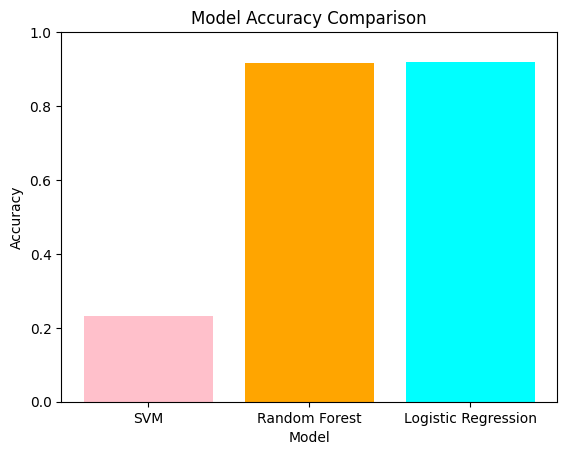

In [ ]:
import matplotlib.pyplot as plt

# Plot comparison of accuracies
accuracies = [svm_accuracy, rf_accuracy, lr_accuracy]
model_names = ['SVM', 'Random Forest', 'Logistic Regression']
plt.bar(model_names, accuracies, color=['pink', 'orange', 'cyan'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)  # Ensures the y-axis ranges from 0 to 1
plt.show()


**6. Apply Randomized Grid Search to Tune Hyperparameters**
*Import grid search library: Use RandomizedSearchCV from sklearn.
*Define parameter grids: Specify the hyperparameters and their ranges to search for each model.
*Initialize grid search: Create instances of RandomizedSearchCV for each model with defined parameter grids.
*Fit grid search: Run the grid search on the training data to find the best hyperparameters.
*Retrieve best parameters: Extract and print the best parameters for each model from the grid search results.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid for Random Forest
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_features': ['auto', 'sqrt'],
    'max_depth': [None, 10, 20],
    'criterion': ['gini', 'entropy']
}

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Apply RandomizedSearchCV
rscv = RandomizedSearchCV(rf_model, param_distributions=param_dist, n_iter=10, cv=5, random_state=42, n_jobs=-1)
rscv.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found: ", rscv.best_params_)
print("Best score from RandomizedSearchCV: ", rscv.best_score_)

# Evaluate the best model from RandomizedSearchCV
best_rf_model = rscv.best_estimator_
best_rf_predictions = best_rf_model.predict(X_test)

best_rf_accuracy = accuracy_score(y_test, best_rf_predictions)
print("Best Random Forest Model Accuracy: ", best_rf_accuracy)
print("Best Random Forest Classification Report:\n", classification_report(y_test, best_rf_predictions))
print("Best Random Forest Confusion Matrix:\n", confusion_matrix(y_test, best_rf_predictions))


Best parameters found:  {'n_estimators': 300, 'max_features': 'sqrt', 'max_depth': 20, 'criterion': 'entropy'}
Best score from RandomizedSearchCV:  0.9192336161580241
Best Random Forest Model Accuracy:  0.9192339447313465
Best Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     56774
           1       0.52      0.02      0.04      4997

    accuracy                           0.92     61771
   macro avg       0.72      0.51      0.50     61771
weighted avg       0.89      0.92      0.88     61771

Best Random Forest Confusion Matrix:
 [[56679    95]
 [ 4894   103]]


**7. Predict and Display the Health Status for a Single Input**
*Select input data: Choose a single input from the dataset for prediction.
*Predict using best model: Use the best-performing model from the previous steps to make a prediction on the selected input.
*Display prediction: Print the predicted health status.
*Explain prediction: Provide a brief explanation of what the predicted health status means.
*Demonstrate practical application: Emphasize how this prediction resembles the working of an AI system in a real-world scenario.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Load the dataset
file_path = 'CVD_cleaned.csv'  # Update this path to where the CSV file is stored
data = pd.read_csv(file_path)

# Encode categorical variables
label_encoders = {}
for column in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

# Split data into features and target
X = data.drop(columns=['Heart_Disease'])
y = data['Heart_Disease']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model
model = RandomForestClassifier(random_state=42)

# Reduce the number of iterations and limit hyperparameter space for quicker execution
param_distributions_reduced = {
    'n_estimators': [int(x) for x in range(100, 501, 100)],  # Reduced range
    'max_depth': [10, 20, 30, None],  # Reduced choices
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'criterion': ['gini', 'entropy']
}

# Set up RandomizedSearchCV with fewer iterations
random_search_reduced = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions_reduced,
    n_iter=20,  # Reduced iterations
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit RandomizedSearchCV
random_search_reduced.fit(X_train, y_train)

# Get the best parameters and best score
best_params_reduced = random_search_reduced.best_params_
best_score_reduced = random_search_reduced.best_score_

print("Best Parameters:", best_params_reduced)
print("Best Score:", best_score_reduced)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20, 'criterion': 'entropy'}
Best Score: 0.9192659956370935
